In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.signal import butter, filtfilt
import emd
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import gc
import os
import matplotlib.pyplot as plt

# EMD CYCLE FEATURE EXTRACTION

In [2]:
def butter_bandpass_filter(data, lowcut=0.5, highcut=30.0, fs=200, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=0)

def get_emd_cycle_features(imfs, sample_rate=200, target_imfs=3):
    """
    Extracts Instantaneous Frequency (IF) and Amplitude (IA) stats 
    from the EMD cycles.
    """
    # Initialize empty features [Mean IF, Std IF, Mean IA, Std IA] per target IMF
    # Shape: (target_imfs * 4,)
    cycle_feats = np.zeros(target_imfs * 4)
    
    # If EMD failed and returned a 1D flatline instead of 2D IMFs
    if imfs.ndim == 1 or imfs.shape[1] == 0:
        return cycle_feats
        
    try:
        # Calculate Instantaneous Phase, Frequency, and Amplitude using Hilbert Transform
        IP, IF, IA = emd.spectra.frequency_transform(imfs, sample_rate, 'hilbert')
        
        # We only look at the first `target_imfs` (usually the most active high/mid frequencies)
        num_imfs_to_process = min(target_imfs, imfs.shape[1])
        
        for j in range(num_imfs_to_process):
            base_idx = j * 4
            # Mean and Std of Instantaneous Frequency for this IMF cycle
            cycle_feats[base_idx] = np.nanmean(IF[:, j])
            cycle_feats[base_idx + 1] = np.nanstd(IF[:, j])
            
            # Mean and Std of Instantaneous Amplitude for this IMF cycle
            cycle_feats[base_idx + 2] = np.nanmean(IA[:, j])
            cycle_feats[base_idx + 3] = np.nanstd(IA[:, j])
            
    except Exception as e:
        # Failsafe for mathematical errors in Hilbert transform on bad signals
        pass
        
    # Replace any potential NaNs generated during transforms with 0
    return np.nan_to_num(cycle_feats)

def process_emd_cycles(filtered_data):
    num_samples, num_channels = filtered_data.shape
    
    # target_imfs=3 * 4 features per IMF = 12 features per channel
    feats_per_channel = 12 
    all_channel_feats = np.zeros((num_channels, feats_per_channel))
    
    for i in range(num_channels):
        channel_signal = filtered_data[:, i]
        
        # SAFETY CHECK: Bypass EMD if signal is completely flat
        if np.var(channel_signal) < 1e-8:
            pass # Leaves zeros for this channel
        else:
            try:
                # Limit IMFs to 4 to drastically speed up processing
                imfs = emd.sift.sift(channel_signal, max_imfs=4)
                
                # Extract the cycle properties directly from the IMFs
                channel_features = get_emd_cycle_features(imfs, sample_rate=200, target_imfs=3)
                all_channel_feats[i, :] = channel_features
                
            except UnboundLocalError:
                pass
            except Exception:
                pass
                
    return all_channel_feats.flatten()


# DATASET PROCESSING LOOP

In [3]:

print("Loading data and extracting EMD Cycle Features...")

data_dir = '/Volumes/PortableSSD/code/practice_hms/classified_eeg_data'

# Map each file to a specific integer class label
target_mapping = {
    'eeg_trials_Seizure.npy': 0,
    'eeg_trials_LPD.npy': 1,
    'eeg_trials_GPD.npy': 2,
    'eeg_trials_LRDA.npy': 3,
    'eeg_trials_GRDA.npy': 4,
    'eeg_trials_Other.npy': 5
}

X_list = []
y_list = []

Loading data and extracting EMD Cycle Features...


# Visualize feature processing

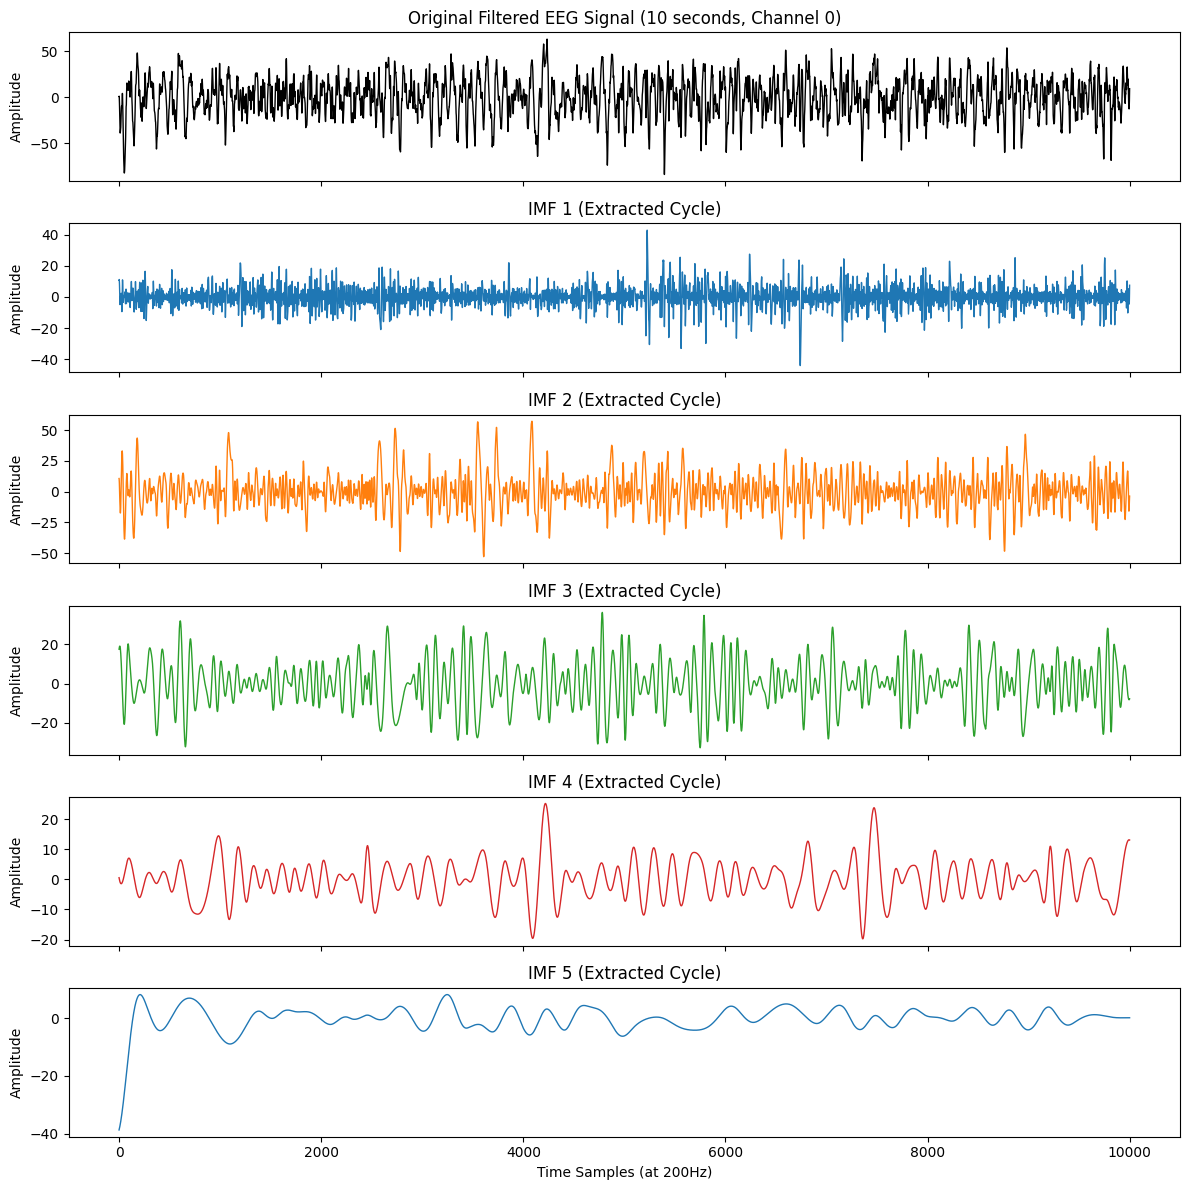

In [6]:
import matplotlib.pyplot as plt
# 1. Grab ONE trial from your Seizure data 
class_data = np.load(data_dir + '/eeg_trials_Seizure.npy', allow_pickle=True)
sample_trial = class_data[0].T

# 2. Extract just the FIRST channel (Channel 0) for plotting
single_channel = sample_trial[:, 0]

# 3. Apply your bandpass filter
filtered_channel = butter_bandpass_filter(single_channel)

# 4. Run EMD
imfs = emd.sift.sift(filtered_channel, max_imfs=4)

# 5. Plot the results
num_imfs = imfs.shape[1]
fig, axes = plt.subplots(num_imfs + 1, 1, figsize=(12, 2 * (num_imfs + 1)), sharex=True)

# Top plot: The filtered original signal
axes[0].plot(filtered_channel, color='black', linewidth=1)
axes[0].set_title("Original Filtered EEG Signal (10 seconds, Channel 0)")
axes[0].set_ylabel("Amplitude")

# Subsequent plots: The IMFs (Cycles)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i in range(num_imfs):
    axes[i+1].plot(imfs[:, i], color=colors[i % len(colors)], linewidth=1)
    axes[i+1].set_title(f"IMF {i+1} (Extracted Cycle)")
    axes[i+1].set_ylabel("Amplitude")

axes[-1].set_xlabel("Time Samples (at 200Hz)")
plt.tight_layout()
plt.show()

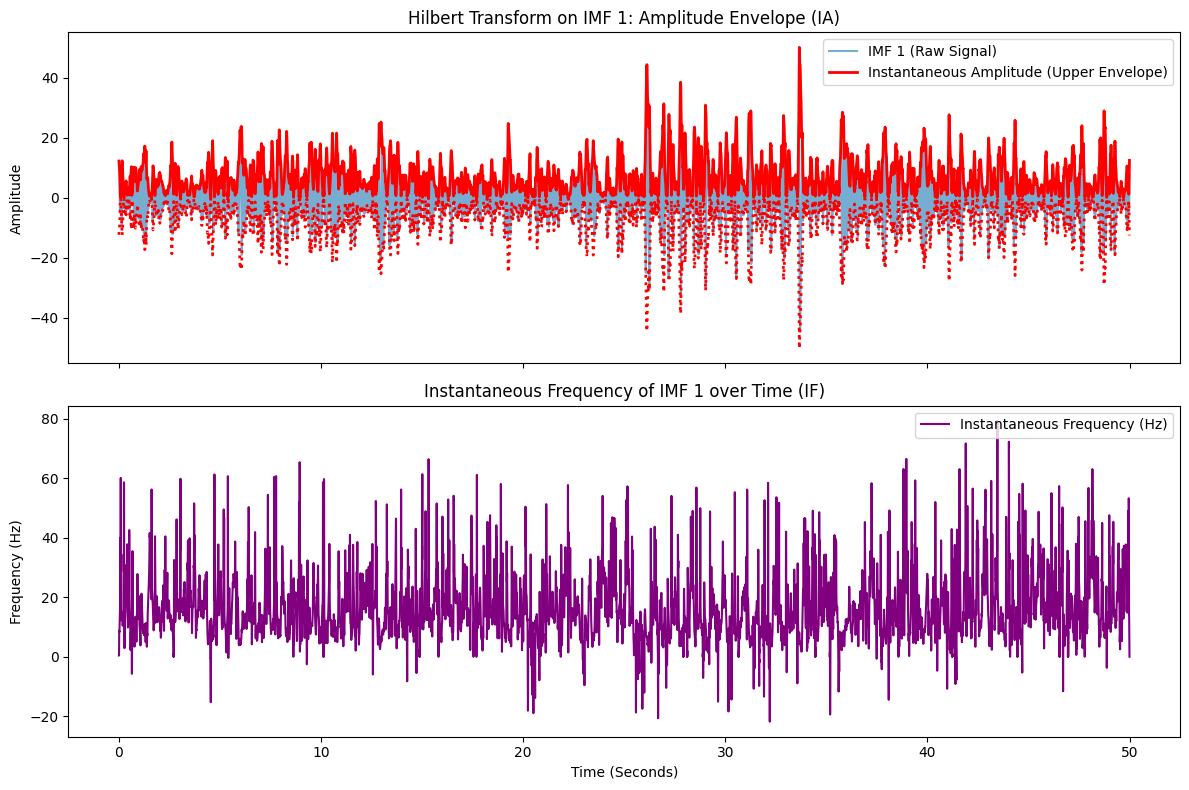

In [7]:

fs = 200 

# 6. 執行 Hilbert 轉換 (同時計算瞬時相位 IP、瞬時頻率 IF 與 瞬時振幅 IA)
IP, IF, IA = emd.spectra.frequency_transform(imfs, fs, 'hilbert')

# 7. 繪製 Hilbert 轉換結果 (以 IMF 1 為例)
fig2, axes2 = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 建立時間軸 (秒) 以利閱讀
time_axis = np.arange(len(filtered_channel)) / fs

# --- 上圖：IMF 1 波形 與 它的瞬時振幅 (包絡線) ---
axes2[0].plot(time_axis, imfs[:, 0], color='#1f77b4', alpha=0.6, label='IMF 1 (Raw Signal)')
axes2[0].plot(time_axis, IA[:, 0], color='red', linewidth=2, label='Instantaneous Amplitude (Upper Envelope)')
axes2[0].plot(time_axis, -IA[:, 0], color='red', linewidth=2, linestyle=':') # 畫下包絡線讓視覺更對稱
axes2[0].set_title("Hilbert Transform on IMF 1: Amplitude Envelope (IA)")
axes2[0].set_ylabel("Amplitude")
axes2[0].legend(loc='upper right')

# --- 下圖：IMF 1 的瞬時頻率 (Instantaneous Frequency) ---
axes2[1].plot(time_axis, IF[:, 0], color='purple', linewidth=1.5, label='Instantaneous Frequency (Hz)')
axes2[1].set_title("Instantaneous Frequency of IMF 1 over Time (IF)")
axes2[1].set_ylabel("Frequency (Hz)")
axes2[1].set_xlabel("Time (Seconds)")
axes2[1].legend(loc='upper right')

# 癲癇高頻震盪通常在特定頻段，可以限制 Y 軸範圍讓圖表更易讀 (視您的資料調整)
# axes2[1].set_ylim(0, 50) 

plt.tight_layout()
plt.show()

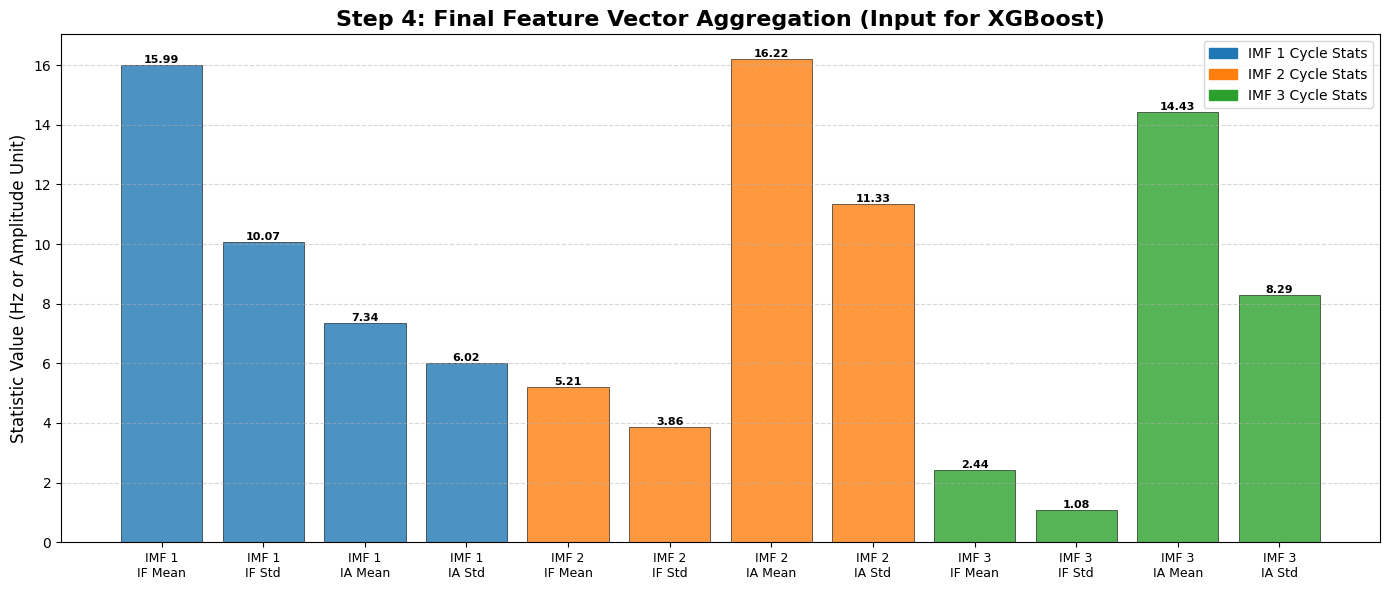


【這段 10 秒腦波在 Channel 0 的最終特徵向量 (1D array for XGBoost)】
[15.9945 10.0663  7.3447  6.0187  5.2131  3.8624 16.22   11.3288  2.4358
  1.077  14.4259  8.2903]
向量長度: 12


In [8]:
# ==========================================
# 接續您的流程：Step 6 (計算 IF/IA) & Step 7 (統計特徵並畫圖)
# ==========================================
import matplotlib.patches as mpatches # 用於製作圖例

# 假設採樣率為 200Hz
fs = 200 
target_imfs = 3 # 我們只取前三個 IMF 做統計

# --- 6. 執行 Hilbert 轉換 ---
# IP: 瞬時相位, IF: 瞬時頻率, IA: 瞬時振幅 (包絡線)
IP, IF, IA = emd.spectra.frequency_transform(imfs, fs, 'hilbert')

# --- 7. 計算統計特徵 (Mean & Std) 並視覺化 ---
# 為了對應您最開始提供的邏輯：[Mean IF, Std IF, Mean IA, Std IA] * 3個IMF = 12個特徵
num_processed = min(target_imfs, imfs.shape[1])

final_features = []
feature_labels = []

# 計算統計量並建立標籤
for i in range(num_processed):
    imf_name = f"IMF {i+1}"
    
    # 瞬時頻率 (IF) 的平均與標準差
    mean_if = np.nanmean(IF[:, i])
    std_if = np.nanstd(IF[:, i])
    
    # 瞬時振幅 (IA) 的平均與標準差
    mean_ia = np.nanmean(IA[:, i])
    std_ia = np.nanstd(IA[:, i])
    
    final_features.extend([mean_if, std_if, mean_ia, std_ia])
    feature_labels.extend([f"{imf_name}\nIF Mean", f"{imf_name}\nIF Std", 
                            f"{imf_name}\nIA Mean", f"{imf_name}\nIA Std"])

# 處理潛在的 NaN 並轉為 NumPy 陣列
final_features_vector = np.nan_to_num(np.array(final_features))

# ==========================================
# 繪製最終特徵向量 (Bar Chart)
# ==========================================
plt.figure(figsize=(14, 6))

# 定義顏色，將同一個 IMF 的四個特徵編為一組 (使用您上一張圖的顏色系統)
imf_colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # 藍, 橘, 綠
bar_colors = []
for c in imf_colors[:num_processed]:
    bar_colors.extend([c] * 4) # 每個 IMF 有 4 個統計量

x_pos = np.arange(len(final_features_vector))

# 畫長條圖
bars = plt.bar(x_pos, final_features_vector, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# 調整 X 軸標籤：將標籤旋轉以利閱讀
plt.xticks(x_pos, feature_labels, rotation=0, fontsize=9)

# 設置標題與座標軸
plt.title("Step 4: Final Feature Vector Aggregation (Input for XGBoost)", fontsize=16, fontweight='bold')
plt.ylabel("Statistic Value (Hz or Amplitude Unit)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 在長條圖上方顯示數值 (處理很小的值，避免重疊)
for bar in bars:
    height = bar.get_height()
    if abs(height) > 0.1:
        plt.text(bar.get_x() + bar.get_width() / 2, height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
    elif abs(height) > 1e-4: # 很小的標準差用科學記號
        plt.text(bar.get_x() + bar.get_width() / 2, height,
                 f'{height:.1e}',
                 ha='center', va='bottom', fontsize=8, color='gray')

# 新增自定義圖例以解釋顏色含義
legend_patches = []
for i in range(num_processed):
    patch = mpatches.Patch(color=imf_colors[i], label=f'IMF {i+1} Cycle Stats')
    legend_patches.append(patch)
plt.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.show()

# --- 同場加映：印出這 1D 向量，讓您看到模型的真實輸入 ---
print("\n" + "="*50)
print("【這段 10 秒腦波在 Channel 0 的最終特徵向量 (1D array for XGBoost)】")
print("="*50)
# 格式化輸出，保留四位小數
print(np.round(final_features_vector, 4))
print("向量長度:", len(final_features_vector))

In [18]:
for filename, label in target_mapping.items():
    filepath = os.path.join(data_dir, filename)
    
    if not os.path.exists(filepath):
        print(f"Skipping {filename} - File not found.")
        continue
        
    print(f"Processing {filename}...")
    
    # Load the specific class file 
    # Assumption: The .npy file contains an array of shape (num_trials, num_samples, num_channels)
    class_data = np.load(filepath)
    
# Inside your processing loop:
    # Optional: class_data[:500] to test a small batch first
    for trial in tqdm(class_data): 
        
        # 1. Transpose the trial from (Channels, Time) to (Time, Channels)
        # Shape goes from (20, 10000) -> (10000, 20)
        trial_t = trial.T
        
        # 2. Crop to the middle 10 seconds to save massive EMD compute time
        # 10 seconds at 200Hz = 2000 samples
        trial_cropped = trial_t[:, :]
        
        # 3. Bandpass Filter (now correctly filtering 2000 time steps)
        filtered_signal = butter_bandpass_filter(trial_cropped)
        
        # 4. Apply EMD & Extract Cycle Features
        features = process_emd_cycles(filtered_signal)
        
        # 5. Store features and the integer label
        X_list.append(features)
        y_list.append(label)
        
    del class_data
    gc.collect()

Processing eeg_trials_Seizure.npy...


100%|██████████| 20933/20933 [2:13:33<00:00,  2.61it/s]  


Processing eeg_trials_LPD.npy...


100%|██████████| 14856/14856 [1:44:43<00:00,  2.36it/s]


Processing eeg_trials_GPD.npy...


...

100%|██████████| 16640/16640 [1:58:35<00:00,  2.34it/s] 


Processing eeg_trials_GRDA.npy...


100%|██████████| 18861/18861 [2:17:51<00:00,  2.28it/s]  


Processing eeg_trials_Other.npy...


100%|██████████| 18808/18808 [4:41:55<00:00,  1.11it/s]     


# TRAIN THE XGBOOST MODEL

In [2]:
X = np.load('/Volumes/PortableSSD/code/practice_hms/X_emd_features.npy')
y = np.load('/Volumes/PortableSSD/code/practice_hms/y_emd_labels.npy')
print(f"Loaded successfully! X: {X.shape}, y: {y.shape}")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    objective='multi:softprob', 
    num_class=6,               # 6 distinct EEG classifications
    n_estimators=5000, 
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mlogloss'     # Logloss is the standard for multi-class classification
)

print("Training XGBoost Classifier...")
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=10                  
)

print("Training complete! Best validation mlogloss:", model.best_score)

Loaded successfully! X: (109800, 240), y: (109800,)
Training XGBoost Classifier...
[0]	validation_0-mlogloss:1.78239
[10]	validation_0-mlogloss:1.69844
[20]	validation_0-mlogloss:1.62625
[30]	validation_0-mlogloss:1.56272
[40]	validation_0-mlogloss:1.50511
[50]	validation_0-mlogloss:1.45338
[60]	validation_0-mlogloss:1.40672
[70]	validation_0-mlogloss:1.36404
[80]	validation_0-mlogloss:1.32484
[90]	validation_0-mlogloss:1.28878
[100]	validation_0-mlogloss:1.25510
[110]	validation_0-mlogloss:1.22374
[120]	validation_0-mlogloss:1.19451
[130]	validation_0-mlogloss:1.16705
[140]	validation_0-mlogloss:1.14140
[150]	validation_0-mlogloss:1.11777
[160]	validation_0-mlogloss:1.09491
[170]	validation_0-mlogloss:1.07337
[180]	validation_0-mlogloss:1.05346
[190]	validation_0-mlogloss:1.03457
[200]	validation_0-mlogloss:1.01636
[210]	validation_0-mlogloss:0.99947
[220]	validation_0-mlogloss:0.98309
[230]	validation_0-mlogloss:0.96706
[240]	validation_0-mlogloss:0.95186
[250]	validation_0-mlogloss:

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import xgboost as xgb # Ensure xgboost is imported for plot_importance

# 1. Generate predictions on your validation dataset
y_pred = model.predict(X_val)

# Print overall accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Overall Validation Accuracy: {accuracy * 100:.2f}%\n")

# Print detailed classification metrics (Precision, Recall, F1-Score)
class_names = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

Overall Validation Accuracy: 93.09%

Classification Report:
              precision    recall  f1-score   support

     Seizure       0.94      0.94      0.94      4287
         LPD       0.94      0.91      0.93      3071
         GPD       0.97      0.95      0.96      3440
        LRDA       0.83      0.98      0.90      3428
        GRDA       0.97      0.94      0.95      3872
       Other       0.94      0.87      0.90      3862

    accuracy                           0.93     21960
   macro avg       0.93      0.93      0.93     21960
weighted avg       0.93      0.93      0.93     21960



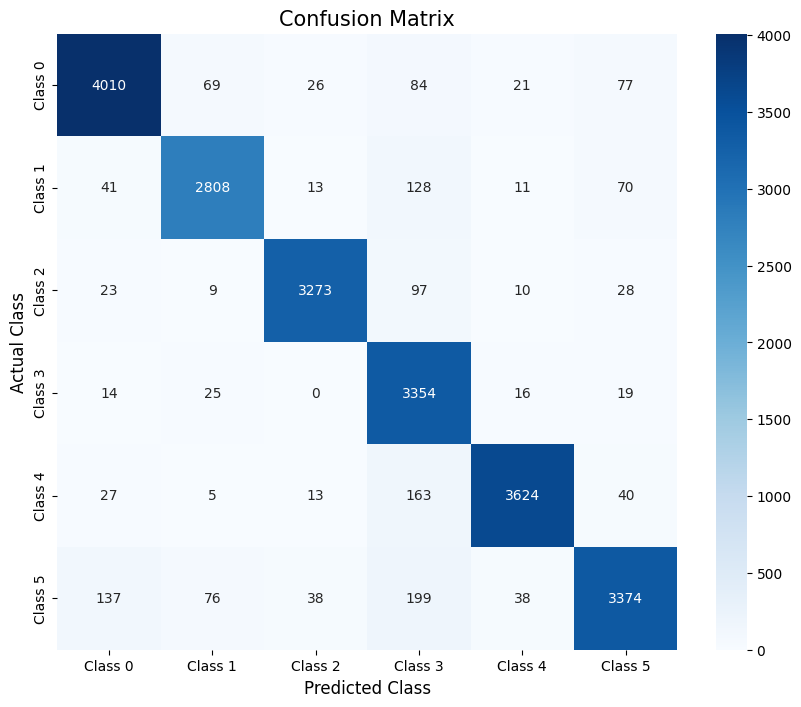

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix', fontsize=15)
    plt.ylabel('Actual Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)
    plt.show()

# 獲取預測結果
y_pred = model.predict(X_val)
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5'] # 根據你的 EEG 標籤修改
plot_confusion_matrix(y_val, y_pred, class_names)

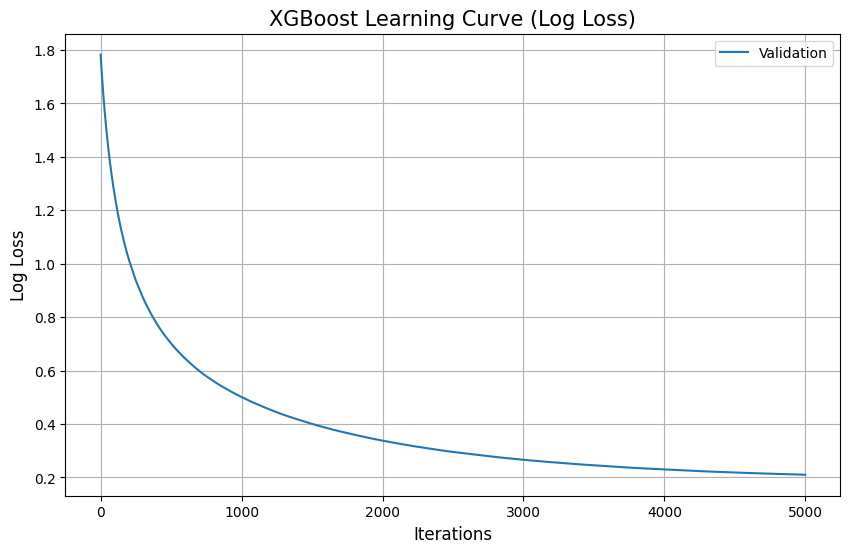

In [27]:
def plot_learning_curves(model):
    results = model.evals_result()
    epochs = len(results['validation_0']['mlogloss'])
    x_axis = range(0, epochs)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_axis, results['validation_0']['mlogloss'], label='Validation')
    # 如果你在 fit 時有傳入 eval_set=[(X_train, y_train), (X_val, y_val)]，則可以畫兩條線
    # plt.plot(x_axis, results['validation_1']['mlogloss'], label='Train')
    
    plt.title('XGBoost Learning Curve (Log Loss)', fontsize=15)
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Log Loss', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curves(model)

<Figure size 1200x800 with 0 Axes>

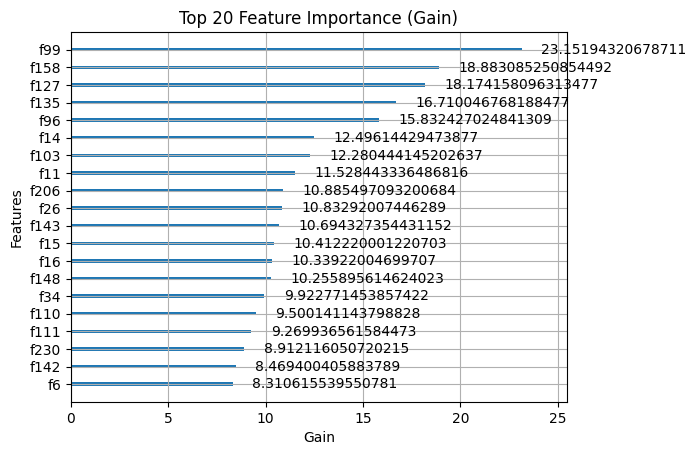

In [28]:
def plot_feature_importance(model, feature_names=None, top_n=20):
    plt.figure(figsize=(12, 8))
    # 可以選擇 'weight', 'gain', 或 'cover'
    xgb.plot_importance(model, max_num_features=top_n, importance_type='gain', 
                        xlabel='Gain', title='Top 20 Feature Importance (Gain)')
    plt.show()

plot_feature_importance(model)

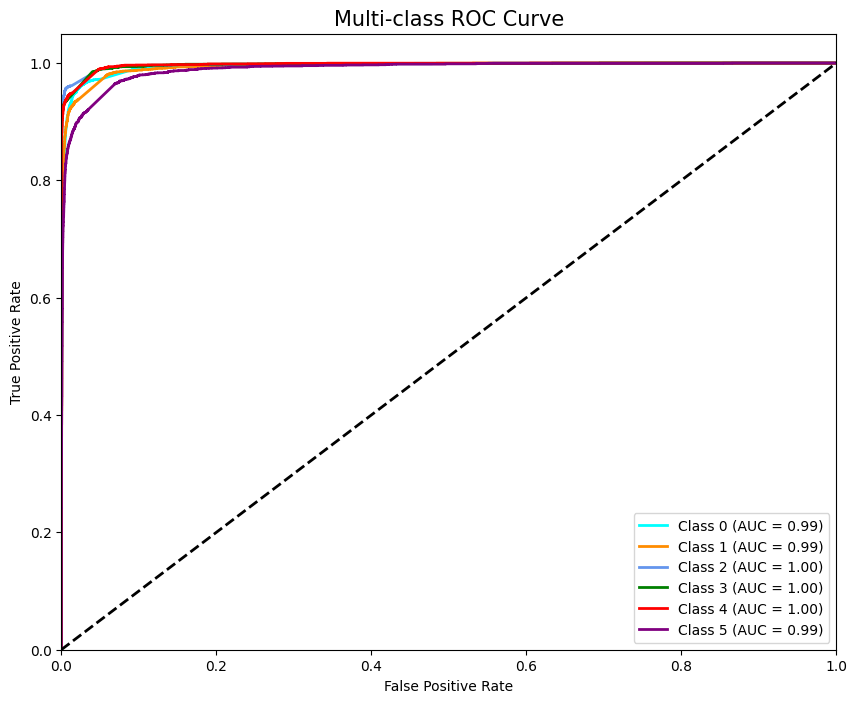

In [29]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_multiclass_roc(model, X_val, y_val, n_classes):
    y_val_bin = label_binarize(y_val, classes=list(range(n_classes)))
    y_score = model.predict_proba(X_val)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve', fontsize=15)
    plt.legend(loc="lower right")
    plt.show()

plot_multiclass_roc(model, X_val, y_val, n_classes=6)